# RCNN Object Detection - Pascal VOC 2012

Klasszikus RCNN implementáció PyTorch és scikit-learn használatával.
ResNet50 backbone, Selective Search régió javaslatok, SVM osztályozás.

**GPU:** NVIDIA GPU (GTX 1660)

## 0. Környezet beállítása

In [1]:
# GPU ellenőrzés
import torch

print(f"PyTorch: {torch.__version__}")
print(f"CUDA elérhető: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("CPU-n folytatjuk, de a feature kinyerés sokkal lassabb lesz.")


PyTorch: 2.12.0+cu130
CUDA elérhető: True
GPU: NVIDIA GeForce GTX 1660


In [2]:
# Könyvtárak importálása

import kagglehub # Kagglehub Pascal VOC 2012 adathalmaz letöltése
import cv2 # Selective Search régiógenerálás
import numpy as np
from PIL import Image # Képbetöltés, régiók kivágása
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.svm import LinearSVC # SVM osztályozó
from sklearn.linear_model import Ridge # Ridge regresszor
from sklearn.preprocessing import StandardScaler
import torch # ResNet50/ResNet18 backbone
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import DataLoader, Dataset
import xml.etree.ElementTree as ET
import os
import random
import pickle
from collections import defaultdict
from pathlib import Path

print(f"OpenCV: {cv2.__version__}")
print(f"ximgproc.segmentation: {hasattr(cv2.ximgproc, 'segmentation')}")


OpenCV: 4.13.0
ximgproc.segmentation: True


## 1. Adathalmaz feltérképezése

Pascal VOC 2012 letöltése kagglehub segítségével, osztályeloszlás, képméretek és bbox statisztikák vizsgálata.

In [3]:
# Pascal VOC 2012 letöltése
path = kagglehub.dataset_download("gopalbhattrai/pascal-voc-2012-dataset")
print(f"Adathalmaz elérési út: {path}")

# Mappaszerkezet
voc_root = Path(path) / "VOC2012_train_val" / "VOC2012_train_val"
annotations_dir = voc_root / "Annotations"
images_dir = voc_root / "JPEGImages"
imgset_dir = voc_root / "ImageSets" / "Main"

# Ellenőrzés: mappa létezik-e
print(f"Annotations: {annotations_dir.exists()}")
print(f"Images: {images_dir.exists()}")

# Képek listája train/val splitből
train_images = []
for class_file in sorted(imgset_dir.glob("*_train.txt")):
    with open(class_file) as f:
        train_images.extend([line.strip().split()[0] for line in f if line.strip()])
train_images = list(set(train_images))

val_images = []
for class_file in sorted(imgset_dir.glob("*_val.txt")):
    with open(class_file) as f:
        val_images.extend([line.strip().split()[0] for line in f if line.strip()])
val_images = list(set(val_images))

random.Random(42).shuffle(train_images)
random.Random(42).shuffle(val_images)

print(f"Train képek: {len(train_images)}")
print(f"Val képek: {len(val_images)}")


Adathalmaz elérési út: /home/joshua/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1
Annotations: True
Images: True
Train képek: 5717
Val képek: 5823


In [4]:
# 20 Osztály listája
VOC_CLASSES = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

# VOC XML annotáció elemzése. Visszaadja a két sarokpont koordinátáit és a kép méretét: [(osztály, [xmin,ymin,xmax,ymax]), ...]
def parse_voc_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    objects = []
    size = root.find('size')
    width = int(size.find('width').text)
    height = int(size.find('height').text)
    for obj in root.findall('object'):
        name = obj.find('name').text
        bbox = obj.find('bndbox')
        xmin = int(bbox.find('xmin').text)
        ymin = int(bbox.find('ymin').text)
        xmax = int(bbox.find('xmax').text)
        ymax = int(bbox.find('ymax').text)
        objects.append((name, [xmin, ymin, xmax, ymax]))
    return objects, (width, height)

# Osztályeloszlás vizsgálata
class_counts = defaultdict(int)
bbox_areas = []
bbox_ratios = []
image_sizes = []

for img_id in train_images[:5000]:
    xml_path = annotations_dir / f"{img_id}.xml"
    if xml_path.exists():
        objects, (w, h) = parse_voc_xml(xml_path)
        image_sizes.append((w, h))
        for cls, bbox in objects:
            class_counts[cls] += 1
            area = (bbox[2] - bbox[0]) * (bbox[3] - bbox[1])
            ratio = (bbox[2] - bbox[0]) / max(bbox[3] - bbox[1], 1)
            bbox_areas.append(area)
            bbox_ratios.append(ratio)

print(" Osztályeloszlás (5000 train kép):")
for cls in VOC_CLASSES:
    print(f"  {cls}: {class_counts[cls]}")

if bbox_areas:
    print(f"\nBbox terület: min={min(bbox_areas):.0f}, max={max(bbox_areas):.0f}, átlag={np.mean(bbox_areas):.0f}")
    print(f"Bbox arány (w/h): átlag={np.mean(bbox_ratios):.2f}")
    print(f"Képméret: min={min(image_sizes)}, max={max(image_sizes)}")
else:
    print("\nFigyelmeztetés: Nem találhatók annotációk 5000 train képben.")


 Osztályeloszlás (5000 train kép):
  aeroplane: 420
  bicycle: 359
  bird: 506
  boat: 449
  bottle: 636
  bus: 272
  car: 1047
  cat: 531
  chair: 1302
  cow: 305
  diningtable: 338
  dog: 682
  horse: 319
  motorbike: 331
  person: 4363
  pottedplant: 479
  sheep: 466
  sofa: 342
  train: 291
  tvmonitor: 362

Bbox terület: min=35, max=249001, átlag=35933
Bbox arány (w/h): átlag=1.11
Képméret: min=(142, 500), max=(500, 500)


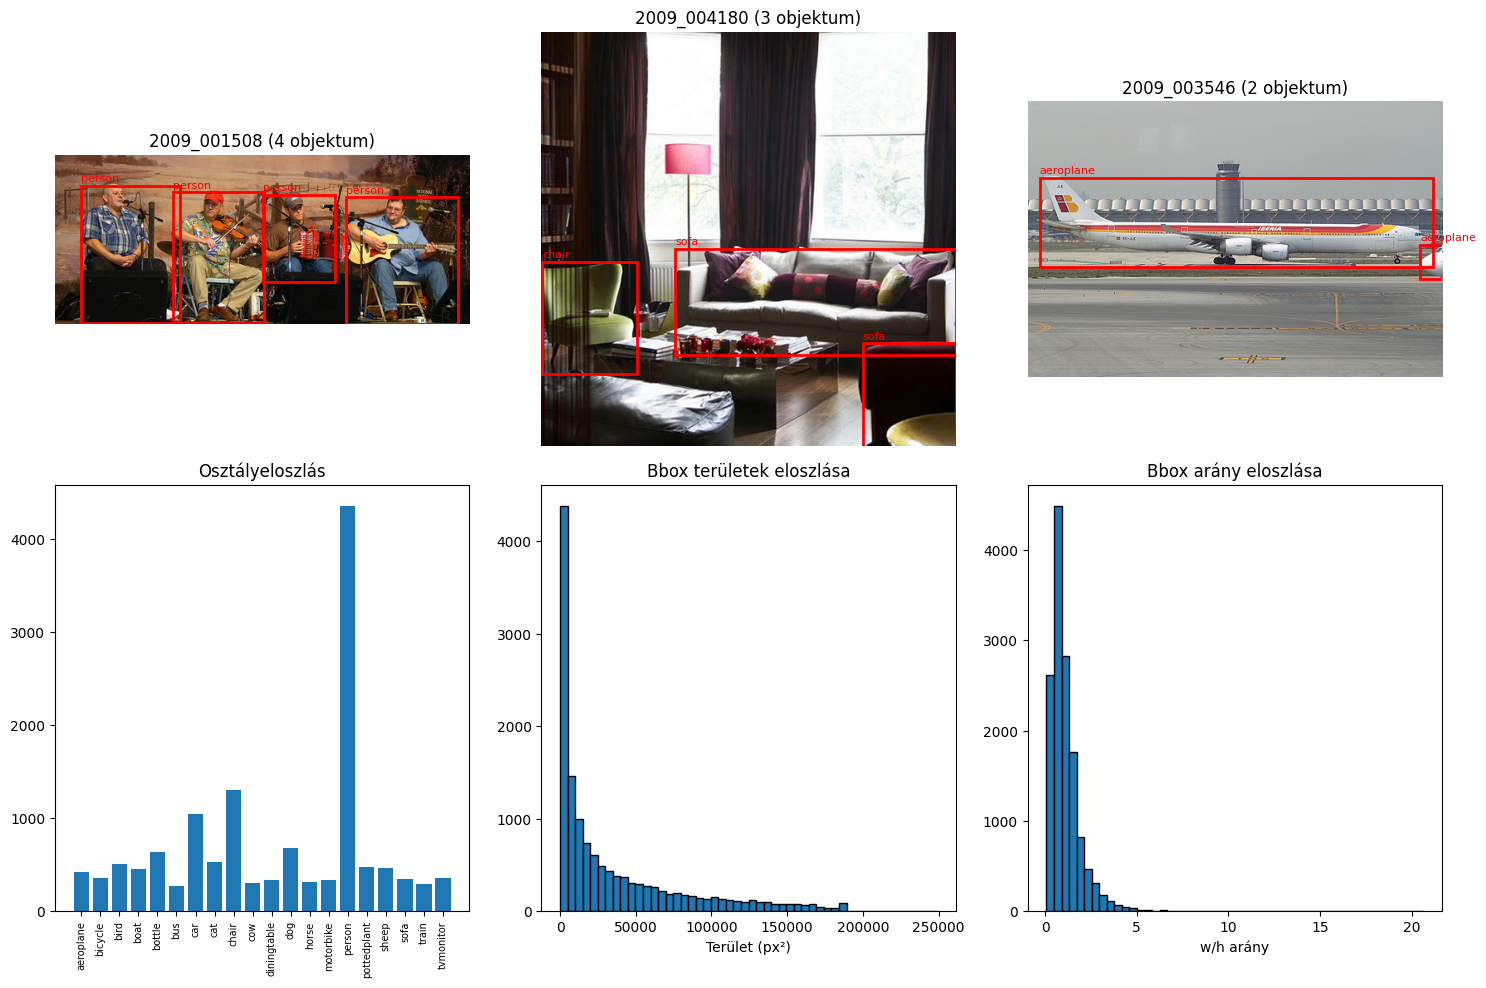

In [5]:
# Vizualizáció: minta képek annotációkkal és statisztikák

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 3 minta kép bboxokkal
sample_ids = random.sample(train_images[:5000], 3)
for i, img_id in enumerate(sample_ids):
    img_path = images_dir / f"{img_id}.jpg"
    img = Image.open(img_path)
    xml_path = annotations_dir / f"{img_id}.xml"
    objects, _ = parse_voc_xml(xml_path)

    axes[0, i].imshow(img)
    for cls, bbox in objects:
        rect = patches.Rectangle((bbox[0], bbox[1]), bbox[2]-bbox[0], bbox[3]-bbox[1],
                                   linewidth=2, edgecolor='red', facecolor='none')
        axes[0, i].add_patch(rect)
        axes[0, i].text(bbox[0], bbox[1]-5, cls, color='red', fontsize=8)
    axes[0, i].set_title(f"{img_id} ({len(objects)} objektum)")
    axes[0, i].axis('off')

# Osztályeloszlás hisztogram
axes[1, 0].bar(range(len(VOC_CLASSES)), [class_counts[c] for c in VOC_CLASSES])
axes[1, 0].set_xticks(range(len(VOC_CLASSES)))
axes[1, 0].set_xticklabels(VOC_CLASSES, rotation=90, fontsize=7)
axes[1, 0].set_title("Osztályeloszlás")

# Bbox terület hisztogram
axes[1, 1].hist(bbox_areas, bins=50, edgecolor='black')
axes[1, 1].set_title("Bbox területek eloszlása")
axes[1, 1].set_xlabel("Terület (px²)")

# Bbox arány hisztogram
axes[1, 2].hist(bbox_ratios, bins=50, edgecolor='black')
axes[1, 2].set_title("Bbox arány eloszlása")
axes[1, 2].set_xlabel("w/h arány")

plt.tight_layout()
plt.show()


## 2. RCNN háló létrehozása

ResNet50 backbone ImageNet előtanítással, régiók átméretezése 224x224-re, SVM osztályozó és Ridge regresszor osztályonként.

In [ ]:
# Feature extractor: ResNet50 utolsó osztályozó réteg nélkül, az avgpool előtti feature map-eket adja vissza
class FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.features = nn.Sequential(*list(resnet.children())[:-2])
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.output_dim = 2048

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return x

# Eszköz beállítása
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
feature_extractor = FeatureExtractor().to(device)
feature_extractor.eval()
print(f"Feature extractor létrehozva. Kimeneti dimenzió: {feature_extractor.output_dim}")
print(f"Eszköz: {device}")


In [ ]:
# Kép transzformáció a ResNet-hez
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# régiók kivágása és feature kinyerés. extractor=None esetén globális feature_extractor.
def extract_region_features(image, regions, batch_size=64, extractor=None):
    if extractor is None:
        extractor = feature_extractor
    features_list = []
    for i in range(0, len(regions), batch_size):
        batch_regions = regions[i:i+batch_size]
        batch_tensors = []
        for (x, y, w, h) in batch_regions:
            crop = image.crop((x, y, x+w, y+h))
            crop_tensor = transform(crop)
            batch_tensors.append(crop_tensor)
        batch = torch.stack(batch_tensors).to(device)
        with torch.no_grad():
            feats = extractor(batch)
        features_list.append(feats.cpu().numpy())
    return np.vstack(features_list) if features_list else np.array([])


In [ ]:
# RCNN modell: backbone + SGD osztályozók + Ridge regresszorok.
class RCNN(nn.Module):
    def __init__(self, num_classes=20, extractor=None):
        super().__init__()
        self.num_classes = num_classes
        self.extractor = extractor
        self.svm_classifiers = {}
        self.ridge_regressors = {}
        self.scaler = StandardScaler()
        self.class_names = VOC_CLASSES

    def extract_features(self, image, regions, batch_size=64):
        return extract_region_features(image, regions, batch_size, extractor=self.extractor)

    # SGD osztályozók tanítása osztályonként, batch-enkénti feldolgozással.
    def fit_svm(self, features, labels, batch_size=10000, n_epochs=10):
        from sklearn.linear_model import SGDClassifier
        from sklearn.utils.class_weight import compute_class_weight

        n_samples = len(labels)

        # StandardScaler inkrementális illesztése
        self.scaler = StandardScaler()
        for start in range(0, n_samples, batch_size):
            end = min(start + batch_size, n_samples)
            self.scaler.partial_fit(features[start:end])

        for cls_idx in range(self.num_classes):
            y = (labels == cls_idx).astype(int)
            n_pos = y.sum()
            if n_pos == 0:
                continue

            class_weights = compute_class_weight(
                'balanced', classes=np.array([0, 1]), y=y
            )
            weight_dict = {0: class_weights[0], 1: class_weights[1]}

            svm = SGDClassifier(
                loss='hinge',
                alpha=1e-3,
                learning_rate='constant',
                eta0=0.001,
                max_iter=1000,
                tol=1e-4,
                random_state=42,
                class_weight=weight_dict,
                average=True,
            )

            classes = np.array([0, 1])
            for epoch in range(n_epochs):
                perm = np.random.permutation(n_samples)
                for start in range(0, n_samples, batch_size):
                    end = min(start + batch_size, n_samples)
                    idx = perm[start:end]
                    X_batch = self.scaler.transform(features[idx])
                    y_batch = y[idx]
                    svm.partial_fit(X_batch, y_batch, classes=classes)

            self.svm_classifiers[cls_idx] = svm

        print(f"SVM-ek tanítva {len(self.svm_classifiers)} osztályra.")

    # Bbox regresszorok tanítása osztályonként.
    def fit_regressors(self, features, labels, gt_boxes, proposals):
        for cls_idx in range(self.num_classes):
            mask = labels == cls_idx
            if mask.sum() < 10:
                continue
            X = self.scaler.transform(features[mask])
            targets = []
            for j in np.where(mask)[0]:
                gt = gt_boxes[j]
                prop = proposals[j]
                prop_w = prop[2] - prop[0]
                prop_h = prop[3] - prop[1]
                prop_cx = prop[0] + prop_w / 2
                prop_cy = prop[1] + prop_h / 2
                gt_w = gt[2] - gt[0]
                gt_h = gt[3] - gt[1]
                gt_cx = gt[0] + gt_w / 2
                gt_cy = gt[1] + gt_h / 2
                tx = (gt_cx - prop_cx) / max(prop_w, 1e-6)
                ty = (gt_cy - prop_cy) / max(prop_h, 1e-6)
                tw = np.log(max(gt_w, 1e-6) / max(prop_w, 1e-6))
                th = np.log(max(gt_h, 1e-6) / max(prop_h, 1e-6))
                targets.append([tx, ty, tw, th])
            targets = np.array(targets)
            ridge = Ridge(alpha=1000)
            ridge.fit(X, targets)
            self.ridge_regressors[cls_idx] = ridge
        print(f"Regresszorok tanítva {len(self.ridge_regressors)} osztályra.")

    # Predikció új képre. Visszaad: (scores, refined_per_class_dict)
    def predict(self, image, regions):
        if len(regions) == 0:
            return [], {}
        feats = self.extract_features(image, regions)
        feats_scaled = self.scaler.transform(feats)
        scores = np.zeros((len(regions), self.num_classes))
        refined_per_class = {}
        for cls_idx in range(self.num_classes):
            if cls_idx in self.svm_classifiers:
                decision = self.svm_classifiers[cls_idx].decision_function(feats_scaled)
                scores[:, cls_idx] = decision
                if cls_idx in self.ridge_regressors:
                    deltas = self.ridge_regressors[cls_idx].predict(feats_scaled)
                    cls_refined = []
                    for j, (x1, y1, x2, y2) in enumerate(regions):
                        w = x2 - x1
                        h = y2 - y1
                        tx, ty, tw, th = deltas[j]
                        cx = x1 + w/2
                        cy = y1 + h/2
                        new_cx = cx + tx * w
                        new_cy = cy + ty * h
                        new_w = w * np.exp(tw)
                        new_h = h * np.exp(th)
                        cls_refined.append([new_cx - new_w/2, new_cy - new_h/2,
                                            new_cx + new_w/2, new_cy + new_h/2])
                    refined_per_class[cls_idx] = np.array(cls_refined)
        return scores, refined_per_class


## 3. Adatelőkészítés

VOC XML parse, Selective Search régió generálás, IoU-alapú címkézés, train/val split.

In [ ]:
# Két bbox IoU-ja kiszámolása. Formátum: [xmin, ymin, xmax, ymax]
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0

from torchvision.ops import nms as tv_nms

# Non-Maximum Suppression: megtartja a legmagasabb pontszámú detekciókat, eltávolítja az átfedőket (IoU > threshold).
def nms(detections, iou_threshold=0.3):
    if len(detections) == 0:
        return []
    scores = torch.tensor([d[0] for d in detections], dtype=torch.float32)
    boxes = torch.tensor([d[1] for d in detections], dtype=torch.float32)
    keep_idx = tv_nms(boxes, scores, iou_threshold).tolist()
    return [detections[i] for i in keep_idx]

# Cache könyvtár létrehozása a Selective Search régiók gyorsítótárazásához.
SS_CACHE_DIR = Path(os.getcwd()) / 'ss_cache'
SS_CACHE_DIR.mkdir(exist_ok=True)

# Selective Search régió javaslatok generálása.
def get_selective_search_regions(image, max_regions=500, img_id=None, mode='fast'):
    # Cache találat esetén gyors visszatérés
    if img_id is not None:
        cache_path = SS_CACHE_DIR / f"{img_id}_{mode}.npy"
        if cache_path.exists():
            regions = np.load(cache_path)
            return regions[:max_regions]

    cv_image = np.array(image.convert('RGB'))
    cv_image = cv_image[:, :, ::-1].copy()
    ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
    ss.setBaseImage(cv_image)
    if mode == 'fast':
        ss.switchToSelectiveSearchFast()
    else:
        ss.switchToSelectiveSearchQuality()
    rects = ss.process()
    regions = []
    for (x, y, w, h) in rects[:max_regions * 3]:
        if w > 20 and h > 20 and w < image.width * 0.9 and h < image.height * 0.9:
            regions.append([x, y, x+w, y+h])
        if len(regions) >= max_regions:
            break
    regions = np.array(regions)

    # Cache-elés a gyorsabb jövőbeli betöltéshez
    if img_id is not None and len(regions) > 0:
        np.save(cache_path, regions)
    return regions

In [ ]:
# Tanító adatok előkészítése: régiók, feature-ök, címkék generálása.
def prepare_training_data(image_ids, annotations_dir, images_dir, max_regions=200, iou_pos=0.5, iou_neg=0.3, neg_subsample_ratio=3, extractor=None):
    import gc

    cache_dir = os.path.join(os.getcwd(), 'feature_cache')
    os.makedirs(cache_dir, exist_ok=True)

    _extractor = extractor if extractor is not None else feature_extractor
    FEATURE_DIM = _extractor.output_dim
    est_max = len(image_ids) * max_regions
    print(f"  Memmap foglalása: {est_max} x {FEATURE_DIM} (float32)")

    feature_path = os.path.join(cache_dir, 'features.dat')
    features_mmap = np.memmap(feature_path, dtype='float32', mode='w+', shape=(est_max, FEATURE_DIM))

    all_labels = []
    all_gt_boxes = []
    all_proposals = []
    sample_idx = 0

    for idx, img_id in enumerate(image_ids):
        if idx % 50 == 0:
            print(f"  Előkészítés: {idx}/{len(image_ids)} (minták: {sample_idx})")

        img_path = images_dir / f"{img_id}.jpg"
        xml_path = annotations_dir / f"{img_id}.xml"

        if not img_path.exists() or not xml_path.exists():
            continue

        image = Image.open(img_path).convert('RGB')
        gt_objects, _ = parse_voc_xml(xml_path)

        if len(gt_objects) == 0:
            continue

        regions = get_selective_search_regions(image, max_regions, img_id=img_id)
        if len(regions) == 0:
            continue

        region_boxes = [(r[0], r[1], r[2]-r[0], r[3]-r[1]) for r in regions]
        feats = extract_region_features(image, region_boxes, extractor=_extractor)

        for j, region in enumerate(regions):
            best_iou = 0
            best_cls_idx = 0
            best_gt_box = None
            for gt_cls, gt_bbox in gt_objects:
                iou = compute_iou(region, gt_bbox)
                if iou > best_iou:
                    best_iou = iou
                    best_cls_idx = VOC_CLASSES.index(gt_cls)
                    best_gt_box = gt_bbox

            if best_iou >= iou_pos:
                features_mmap[sample_idx] = feats[j].astype('float32')
                all_labels.append(best_cls_idx)
                all_gt_boxes.append(best_gt_box)
                all_proposals.append(region)
                sample_idx += 1
            elif best_iou < iou_neg:
                features_mmap[sample_idx] = feats[j].astype('float32')
                all_labels.append(-1)
                all_gt_boxes.append(None)
                all_proposals.append(region)
                sample_idx += 1

        del feats, region_boxes
        if idx % 10 == 0:
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    features_mmap.flush()

    all_labels = np.array(all_labels, dtype=np.int32)

    n_pos = (all_labels >= 0).sum()
    n_neg = (all_labels == -1).sum()
    print(f"  Pozitív minták: {n_pos}, Negatív minták: {n_neg}")

    # Negatív alulmintavételezés
    if n_pos > 0 and n_neg > n_pos * neg_subsample_ratio:
        neg_indices = np.where(all_labels == -1)[0]
        pos_indices = np.where(all_labels >= 0)[0]
        max_neg = int(n_pos * neg_subsample_ratio)
        keep_neg = np.random.RandomState(42).choice(neg_indices, size=max_neg, replace=False)
        keep_indices = np.sort(np.concatenate([pos_indices, keep_neg]))

        # memmap frissítése csak a megtartott mintákkal
        final_feat_path = os.path.join(cache_dir, 'features_final.dat')
        final_mmap = np.memmap(final_feat_path, dtype='float32', mode='w+', shape=(len(keep_indices), FEATURE_DIM))
        copy_batch = 10000
        for start in range(0, len(keep_indices), copy_batch):
            end = min(start + copy_batch, len(keep_indices))
            final_mmap[start:end] = features_mmap[keep_indices[start:end]]
        final_mmap.flush()
        del features_mmap
        os.remove(feature_path)

        all_labels = all_labels[keep_indices]
        all_gt_boxes = [all_gt_boxes[i] for i in keep_indices]
        all_proposals = [all_proposals[i] for i in keep_indices]
        sample_idx = len(keep_indices)

        print(f"  Negatív alulmintavételezés után: {len(all_labels)} minta (max {neg_subsample_ratio}:1 arány)")
    else:
        # Ha nincs szükség alulmintavételezésre, csak egy új memmap-et hozunk létre a pontos mérettel
        final_feat_path = os.path.join(cache_dir, 'features_final.dat')
        final_mmap = np.memmap(final_feat_path, dtype='float32', mode='w+', shape=(sample_idx, FEATURE_DIM))
        copy_batch = 10000
        for start in range(0, sample_idx, copy_batch):
            end = min(start + copy_batch, sample_idx)
            final_mmap[start:end] = features_mmap[start:end]
        final_mmap.flush()
        del features_mmap
        os.remove(feature_path)

    # Végső memmap és metaadatok visszaadása
    final_path = os.path.join(cache_dir, 'features_final.dat')
    final_n_samples = len(all_labels)

    return {
        'features_mmap': final_mmap,
        'features_path': final_path,
        'n_samples': final_n_samples,
        'labels': all_labels,
        'gt_boxes': all_gt_boxes,
        'proposals': all_proposals,
        'feature_dim': FEATURE_DIM,
        'cache_dir': cache_dir,
    }


## 4. Háló tanítása és eredmények értékelése

CNN feature kinyerés, SVM tanítás, bbox regresszor tanítás, mAP kiértékelés.

In [ ]:
# Adatelőkészítés végrehajtása
print("Adatelőkészítés a train halmazon...")
N_TRAIN = 5000
train_subset = train_images[:N_TRAIN]

data = prepare_training_data(
    train_subset, annotations_dir, images_dir, max_regions=200, neg_subsample_ratio=3
)

print(f"\nTrain adatok:")
print(f"  Feature mátrix: {data['n_samples']} x {data['feature_dim']} (disk: {data['cache_dir']})")
print(f"  Pozitív minták: {(data['labels'] >= 0).sum()}")
print(f"  Negatív (háttér) minták: {(data['labels'] == -1).sum()}")
print(f"  Feature fájl: {data['features_path']}")

unique, counts = np.unique(data['labels'][data['labels'] >= 0], return_counts=True)
for cls_idx, cnt in zip(unique, counts):
    print(f"  {VOC_CLASSES[cls_idx]}: {cnt}")


In [ ]:
# RCNN modell tanítása (SGDClassifier + memmap)
import gc
rcnn = RCNN(num_classes=20)

rcnn.fit_svm(data['features_mmap'], data['labels'])

print("\nBbox regresszorok tanítása...")
rcnn.fit_regressors(
    data['features_mmap'],
    data['labels'],
    data['gt_boxes'],
    data['proposals']
)

# Memmap felszabadítása tanítás után
del data['features_mmap']
gc.collect()


print("\nTanítás kész.")


In [ ]:
# All point Average Precision számítása.
def compute_ap(precisions, recalls):
    recalls = np.concatenate(([0.], recalls, [1.]))
    precisions = np.concatenate(([0.], precisions, [0.]))

    # Precision monoton csökkenővé tétele a recall növekedésével
    for i in range(len(precisions) - 1, 0, -1):
        precisions[i - 1] = max(precisions[i - 1], precisions[i])

    # Recall változásainak helyeinek meghatározása
    indices = np.where(recalls[1:] != recalls[:-1])[0]
    return np.sum((recalls[indices + 1] - recalls[indices]) * precisions[indices + 1])

# Modell kiértékelése: per-class AP és mAP (NMS-sel).
def evaluate_model(model, image_ids, annotations_dir, images_dir, iou_threshold=0.5):
    target_classes = model.class_names
    all_detections = defaultdict(list)
    all_groundtruth = defaultdict(list)

    for i, img_id in enumerate(image_ids):
        if i % 50 == 0:
            print(f"  Eval: {i}/{len(image_ids)}")
        img_path = images_dir / f"{img_id}.jpg"
        xml_path = annotations_dir / f"{img_id}.xml"

        if not img_path.exists() or not xml_path.exists():
            continue

        image = Image.open(img_path).convert('RGB')
        gt_objects, _ = parse_voc_xml(xml_path)

        for gt_cls, gt_bbox in gt_objects:
            all_groundtruth[gt_cls].append((gt_bbox, img_id))

        regions = get_selective_search_regions(image, max_regions=500, img_id=img_id, mode='fast')
        if len(regions) == 0:
            continue

        scores, refined_per_class = model.predict(image, regions)

        for cls_idx, cls_name in enumerate(target_classes):
            cls_scores = scores[:, cls_idx]
            # NMS előtti jelöltek: top 50 pontszám alapján
            top_indices = np.argsort(cls_scores)[-100:]
            candidates = []

            for idx in top_indices:
                #if cls_scores[idx] > 0:
                if cls_idx in refined_per_class:
                    bbox = refined_per_class[cls_idx][idx]
                else:
                    bbox = regions[idx]
                candidates.append((cls_scores[idx], bbox, img_id))

            # NMS alkalmazása osztályonként
            kept = nms(candidates, iou_threshold=0.3)
            all_detections[cls_name].extend(kept)

    ap_per_class = {}
    for cls_name in target_classes:
        dets = sorted(all_detections[cls_name], key=lambda x: x[0], reverse=True)
        gts = all_groundtruth[cls_name]

        if len(dets) == 0 and len(gts) == 0:
            ap_per_class[cls_name] = 0
            continue
        if len(dets) == 0 or len(gts) == 0:
            ap_per_class[cls_name] = 0
            continue

        tp = np.zeros(len(dets))
        fp = np.zeros(len(dets))
        gt_matched = defaultdict(set)

        for i, (conf, bbox, img_id) in enumerate(dets):
            best_iou = 0
            best_gt_idx = -1
            for j, (gt_bbox, gt_img_id) in enumerate(gts):
                if gt_img_id == img_id and j not in gt_matched[img_id]:
                    iou = compute_iou(bbox, gt_bbox)
                    if iou > best_iou:
                        best_iou = iou
                        best_gt_idx = j

            if best_iou >= iou_threshold:
                tp[i] = 1
                gt_matched[img_id].add(best_gt_idx)
            else:
                fp[i] = 1

        tp_cum = np.cumsum(tp)
        fp_cum = np.cumsum(fp)
        recalls = tp_cum / max(len(gts), 1)
        precisions = tp_cum / np.maximum(tp_cum + fp_cum, 1)

        ap_per_class[cls_name] = compute_ap(precisions, recalls)

    mAP = np.mean(list(ap_per_class.values()))
    return ap_per_class, mAP

In [ ]:
# Kiértékelés a validációs halmazon
print("Kiértékelés a validációs halmazon...")
N_VAL = 1000
val_subset = val_images[:N_VAL]

ap_per_class, mAP = evaluate_model(rcnn, val_subset, annotations_dir, images_dir)

print(f"\nKiértékelési eredmények (IoU > 0.5):")
print(f"mAP: {mAP:.4f}")
print(f"\nPer-class AP:")
for cls_name in VOC_CLASSES:
    print(f"  {cls_name}: {ap_per_class[cls_name]:.4f}")


In [ ]:
# Eredmények vizualizációja
fig, ax = plt.subplots(figsize=(12, 5))
ap_values = [ap_per_class[cls] for cls in VOC_CLASSES]
colors = ['green' if v > 0.1 else 'orange' if v > 0.05 else 'red' for v in ap_values]
ax.bar(range(len(VOC_CLASSES)), ap_values, color=colors)
ax.axhline(y=mAP, color='blue', linestyle='--', label=f'mAP = {mAP:.4f}')
ax.set_xticks(range(len(VOC_CLASSES)))
ax.set_xticklabels(VOC_CLASSES, rotation=90, fontsize=8)
ax.set_ylabel('Average Precision')
ax.set_title('Per-class AP a validációs halmazon')
ax.legend()
plt.tight_layout()
plt.show()


## 5. Architektúra módosítás és hiperparaméter optimalizálás

IoU küszöbértékek, régiók száma és SVM C paraméter hangolása. Különböző backbone architektúrák összehasonlítása.

In [ ]:
# Hiperparaméter, különösen az IoU pozitív küszöb optimalizálása a train/val halmazokon.
import gc
print("Hiperparaméter optimalizálás\n")

N_OPT_TRAIN = 500
N_OPT_VAL = 100
opt_train = train_images[:N_OPT_TRAIN]
opt_val = val_images[:N_OPT_VAL]

results = []

for iou_pos in [0.4, 0.5, 0.6]:
    print(f"\nIoU pozitív küszöb: {iou_pos}")

    opt_data = prepare_training_data(
        opt_train, annotations_dir, images_dir, max_regions=100, iou_pos=iou_pos
    )

    if opt_data['n_samples'] == 0:
        continue

    opt_rcnn = RCNN(num_classes=20)
    opt_rcnn.fit_svm(opt_data['features_mmap'], opt_data['labels'])

    if (opt_data['labels'] >= 0).sum() >= 10:
        opt_rcnn.fit_regressors(
            opt_data['features_mmap'],
            opt_data['labels'],
            opt_data['gt_boxes'],
            opt_data['proposals']
        )

    _, opt_mAP = evaluate_model(opt_rcnn, opt_val, annotations_dir, images_dir)
    results.append({"param": f"IoU={iou_pos}", "mAP": opt_mAP})
    print(f"  mAP: {opt_mAP:.4f}")

    del opt_data['features_mmap']
    gc.collect()

print("\nOptimalizálási összefoglaló")
for r in results:
    print(f"  {r['param']}: mAP={r['mAP']:.4f}")

best_result = max(results, key=lambda x: x["mAP"])
print(f"\nLegjobb: {best_result['param']} (mAP={best_result['mAP']:.4f})")


In [ ]:
# ResNet18 vs ResNet50 Backbone architektúrák összehasonlítása
import gc
print("\nArchitektúra összehasonlítás\n")

# 1) ResNet18 feature extractor osztály
class ResNet18Extractor(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.features = nn.Sequential(*list(resnet.children())[:-2])
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.output_dim = 512

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        return torch.flatten(x, 1)

rn18_extractor = ResNet18Extractor().to(device)
rn18_extractor.eval()

print(f"  ResNet50 dimenzió: {feature_extractor.output_dim}")
print(f"  ResNet18 dimenzió: {rn18_extractor.output_dim}")

# 2）Azonos méretű alhalmaz kiválasztása a train/val halmazokból az architektúrák összehasonlításához.
N_ARCH_TRAIN = 1000
N_ARCH_VAL = 200
arch_train = train_images[:N_ARCH_TRAIN]
arch_val = val_images[:N_ARCH_VAL]

# 3) ResNet18 újratanítása ugyanazon alhalmazon + kiértékelés (fair összehasonlítás)
print("\n[ResNet18] adatelőkészítés...")
data_rn18 = prepare_training_data(
    arch_train, annotations_dir, images_dir,
    max_regions=100, extractor=rn18_extractor
)

print("[ResNet18] tanítás...")
rcnn_rn18 = RCNN(num_classes=20, extractor=rn18_extractor)
rcnn_rn18.fit_svm(data_rn18['features_mmap'], data_rn18['labels'])
if (data_rn18['labels'] >= 0).sum() >= 10:
    rcnn_rn18.fit_regressors(
        data_rn18['features_mmap'],
        data_rn18['labels'],
        data_rn18['gt_boxes'],
        data_rn18['proposals']
    )

print("[ResNet18] kiértékelés...")
_, mAP_rn18 = evaluate_model(rcnn_rn18, arch_val, annotations_dir, images_dir)

del data_rn18['features_mmap']
gc.collect()
torch.cuda.empty_cache()

# 4) ResNet50 újratanítása ugyanazon alhalmazon + kiértékelés (fair összehasonlítás)
print("\n[ResNet50] adatelőkészítés...")
data_rn50 = prepare_training_data(
    arch_train, annotations_dir, images_dir,
    max_regions=100
)

print("[ResNet50] tanítás...")
rcnn_rn50 = RCNN(num_classes=20)
rcnn_rn50.fit_svm(data_rn50['features_mmap'], data_rn50['labels'])
if (data_rn50['labels'] >= 0).sum() >= 10:
    rcnn_rn50.fit_regressors(
        data_rn50['features_mmap'],
        data_rn50['labels'],
        data_rn50['gt_boxes'],
        data_rn50['proposals']
    )

print("[ResNet50] kiértékelés...")
_, mAP_rn50 = evaluate_model(rcnn_rn50, arch_val, annotations_dir, images_dir)

del data_rn50['features_mmap']
gc.collect()
torch.cuda.empty_cache()

# 5) Eredmények összehasonlítása és összefoglalása
print("\nArchitektúra összehasonlítás eredmény")
print(f"  ResNet18 (dim=512):  mAP = {mAP_rn18:.4f}")
print(f"  ResNet50 (dim=2048): mAP = {mAP_rn50:.4f}")

# Eredmények táblázatos formában
arch_results = [
    {"backbone": "ResNet18", "dim": 512,  "mAP": mAP_rn18},
    {"backbone": "ResNet50", "dim": 2048, "mAP": mAP_rn50},
]


In [ ]:
# Eredmények vizualizációja: oszlopdiagram mAP értékekkel és dimenziók megjelenítésével
fig, ax = plt.subplots(figsize=(8, 5))
names = [r['backbone'] for r in arch_results]
maps  = [r['mAP'] for r in arch_results]
dims  = [r['dim'] for r in arch_results]
bars = ax.bar(names, maps, color=['steelblue', 'darkorange'])
y_offset = max(maps) * 0.04 if max(maps) > 0 else 0.001
for bar, m, d in zip(bars, maps, dims):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + y_offset,
            f'mAP={m:.4f}\ndim={d}', ha='center', fontsize=10)
ax.set_ylabel('mAP')
ax.set_title('Backbone architektúrák összehasonlítása (azonos train/val subset)')
ax.set_ylim(0, max(maps) * 1.4 if max(maps) > 0 else 0.01)
plt.tight_layout()
plt.show()

## 6. Tanítóadat mennyiség vizsgálata

Különböző méretű tanítóhalmazok (10%, 25%, 50%, 100%) és osztályszám variációk hatása a teljesítményre.

In [ ]:
# Tanítóadat mennyiség hatásának vizsgálata
import gc
print("Tanítóadat mennyiség vs. teljesítmény\n")

data_fractions = [0.1, 0.25, 0.5, 1.0]
N_DATA_TRAIN_BASE = 1000
N_DATA_VAL = 200
data_val = val_images[:N_DATA_VAL]

quantity_results = []

for frac in data_fractions:
    n_train = int(N_DATA_TRAIN_BASE * frac)
    subset = train_images[:n_train]
    print(f"\nTanítóhalmaz: {n_train} kép ({frac*100:.0f}%)")

    train_data = prepare_training_data(
        subset, annotations_dir, images_dir, max_regions=100
    )

    if train_data['n_samples'] == 0:
        continue

    data_rcnn = RCNN(num_classes=20)
    data_rcnn.fit_svm(train_data['features_mmap'], train_data['labels'])

    if (train_data['labels'] >= 0).sum() >= 10:
        data_rcnn.fit_regressors(
            train_data['features_mmap'],
            train_data['labels'],
            train_data['gt_boxes'],
            train_data['proposals']
        )

    _, data_mAP = evaluate_model(data_rcnn, data_val, annotations_dir, images_dir)
    quantity_results.append({"frac": frac, "n_train": n_train, "mAP": data_mAP})
    print(f"  mAP: {data_mAP:.4f}")

    del train_data['features_mmap']
    gc.collect()


In [ ]:
# Vizualizáció: adatmennyiség vs. mAP
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if quantity_results:
    n_trains = [r['n_train'] for r in quantity_results]
    maps = [r['mAP'] for r in quantity_results]

    axes[0].plot(n_trains, maps, 'o-', linewidth=2, markersize=8)
    axes[0].set_xlabel('Tanító képek száma')
    axes[0].set_ylabel('mAP')
    axes[0].set_title('Tanítóadat mennyiség hatása')
    axes[0].grid(True)

    axes[1].bar([f"{r['n_train']} kép" for r in quantity_results], maps, color='steelblue')
    axes[1].set_ylabel('mAP')
    axes[1].set_title('mAP különböző tanítóhalmaz méreteknél')

    y_offset = max(maps) * 0.03 if max(maps) > 0 else 0.001
    for i, v in enumerate(maps):
        axes[1].text(i, v + y_offset, f'{v:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


In [ ]:
# Osztályszám variációk vizsgálata
import gc
print("\nOsztályszám variációk\n")

class_counts_to_test = [5, 10, 20]
class_count_results = []

for n_classes in class_counts_to_test:
    selected_classes = VOC_CLASSES[:n_classes]
    print(f"\nOsztályok száma: {n_classes}")

    n_cc_train = min(500, len(train_images))
    cc_train = train_images[:n_cc_train]

    cc_data = prepare_training_data(
        cc_train, annotations_dir, images_dir, max_regions=100
    )

    if cc_data['n_samples'] == 0:
        continue

    # Csak a valid osztályok és háttér maradjon, új memmap létrehozása a szűrt adatokkal.
    cc_labels = cc_data['labels'].copy()
    FEATURE_DIM = cc_data['feature_dim']
    N_ALL = cc_data['n_samples']

    # 1) Kiválasztjuk a valid mintákat: -1 (háttér) és a kiválasztott osztályok
    valid_mask = np.zeros(N_ALL, dtype=bool)
    valid_mask[cc_labels == -1] = True
    valid_mask[(cc_labels >= 0) & (cc_labels < n_classes)] = True
    valid_indices = np.where(valid_mask)[0]

    # 2) Eredeti memmap megnyitása olvasásra
    src_mmap = np.memmap(
        cc_data['features_path'], dtype='float32', mode='r',
        shape=(N_ALL, FEATURE_DIM)
    )

    # 3) Új memmap létrehozása csak a valid minták számára, batch-enkénti másolással
    sub_path = os.path.join(cc_data['cache_dir'], f'features_sub_{n_classes}.dat')
    cc_features = np.memmap(
        sub_path, dtype='float32', mode='w+',
        shape=(len(valid_indices), FEATURE_DIM)
    )
    copy_batch = 5000
    for start in range(0, len(valid_indices), copy_batch):
        end = min(start + copy_batch, len(valid_indices))
        cc_features[start:end] = src_mmap[valid_indices[start:end]]
    cc_features.flush()

    # Eredeti memmap és referencia törlése a memória felszabadításához
    del src_mmap
    del cc_data['features_mmap']
    gc.collect()

    cc_labels = cc_labels[valid_mask]

    cc_rcnn = RCNN(num_classes=n_classes)
    cc_rcnn.class_names = selected_classes

    cc_rcnn.fit_svm(cc_features, cc_labels)

    # Regresszorok tanítása csak a valid mintákra
    if (cc_labels >= 0).sum() >= 10:
        cc_gt_boxes = [cc_data['gt_boxes'][i] for i in np.where(valid_mask)[0]]
        cc_proposals = [cc_data['proposals'][i] for i in np.where(valid_mask)[0]]
        cc_rcnn.fit_regressors(cc_features, cc_labels, cc_gt_boxes, cc_proposals)

    pos_mask = cc_labels >= 0
    train_cls_counts = [np.sum(cc_labels == i) for i in range(n_classes)]
    print(f"  Osztályonkénti mintaszám: {train_cls_counts}")
    print(f"  Összes pozitív minta: {pos_mask.sum()}")

    _, cc_mAP = evaluate_model(cc_rcnn, val_images[:5], annotations_dir, images_dir) #100
    class_count_results.append({
        "n_classes": n_classes,
        "samples_per_class": np.mean(train_cls_counts),
        "mAP": cc_mAP,
    })
    print(f"  mAP: {cc_mAP:.4f}")

print("\nOsztályszám összefoglaló")
for r in class_count_results:
    print(f"  {r['n_classes']} osztály: átlag {r['samples_per_class']:.0f} minta/osztály")


## 7. Végső eredmény

Összefoglaló táblázatok, optimalizálás előtti/utáni összehasonlítás, következtetések.

In [ ]:
# Végső összefoglaló
print("RCNN Pascal VOC 2012 - Végeredmények\n")

print("Architektúra: RCNN")
print("Backbone: ResNet50")
print("Régió javaslat: Selective Search")
print("Osztályozó: SGDClassifier (hinge loss)")
print("Bbox regresszor: Ridge regresszió")
print("Osztályok száma: 20")
print()

print("Eredmények összefoglaló")
print(f"Végső mAP: {mAP:.4f}")

if results:
    print("\nHiperparaméter optimalizálás")
    for r in results:
        print(f"  {r['param']}: mAP={r['mAP']:.4f}")

if quantity_results:
    print("\nAdatmennyiség vizsgálat")
    for r in quantity_results:
        print(f"  {r['n_train']} kép: mAP={r['mAP']:.4f}")


In [ ]:
# Végső összefoglaló ábra
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ap_values = [ap_per_class[cls] for cls in VOC_CLASSES]
axes[0].barh(range(len(VOC_CLASSES)), ap_values, color='steelblue')
axes[0].set_yticks(range(len(VOC_CLASSES)))
axes[0].set_yticklabels(VOC_CLASSES, fontsize=8)
axes[0].set_xlabel('Average Precision')
axes[0].set_title('Végső per-class AP')
axes[0].axvline(x=mAP, color='red', linestyle='--', label=f'mAP={mAP:.4f}')
axes[0].legend()

if quantity_results:
    n_trains = [r['n_train'] for r in quantity_results]
    maps_q = [r['mAP'] for r in quantity_results]
    axes[1].plot(n_trains, maps_q, 'o-', linewidth=2, markersize=10, color='darkgreen')
    axes[1].set_xlabel('Tanító képek száma')
    axes[1].set_ylabel('mAP')
    axes[1].set_title('Tanítóadat mennyiség vs. mAP')
    axes[1].grid(True)

plt.tight_layout()
plt.show()


## 8. Modell mentése és betöltése

Tanított modell (SVM-ek, regresszorok, ResNet50 súlyok) perzisztens mentése és visszatöltése.

In [ ]:
# Modell mentése és betöltése — lokális GPU-ra
MODEL_DIR = os.path.join(os.getcwd(), 'model')
os.makedirs(MODEL_DIR, exist_ok=True)

def save_rcnn(model, path=None):
    if path is None:
        path = os.path.join(MODEL_DIR, 'rcnn_model.pkl')
    state = {
        'svm_classifiers': model.svm_classifiers,
        'ridge_regressors': model.ridge_regressors,
        'scaler': model.scaler,
        'num_classes': model.num_classes,
        'class_names': model.class_names,
    }
    with open(path, 'wb') as f:
        pickle.dump(state, f)
    print(f"Modell mentve: {path}")

def load_rcnn(path=None):
    if path is None:
        path = os.path.join(MODEL_DIR, 'rcnn_model.pkl')
    model = RCNN(num_classes=20)
    with open(path, 'rb') as f:
        state = pickle.load(f)
    model.svm_classifiers = state['svm_classifiers']
    model.ridge_regressors = state['ridge_regressors']
    model.scaler = state['scaler']
    model.num_classes = state.get('num_classes', 20)
    model.class_names = state.get('class_names', VOC_CLASSES)
    print("Modell betöltve. (Backbone: ResNet50)")
    return model

# Tanítás után automatikusan menti a modellt
if 'rcnn' in dir():
    save_rcnn(rcnn)
    print(f"\nMentési könyvtár: {MODEL_DIR}")
else:
    print("\nA modell betöltéséhez használd a load_rcnn()-t")


## 9. Demo

Detektálás bemeneti képeken — a lokálisan elmentett modell betöltésével.

In [ ]:
# Demo: lokálisan elmentett modell betöltése és futtatása véletlenszerű validációs képeken
print("RCNN Objektumdetektálás — modell betöltése...\n")

# Modell betöltése a model/ könyvtárból
rcnn = load_rcnn()


In [ ]:
# Objektumok detektálása és vizualizációja egy képen (NMS-sel).
def detect_and_visualize(image, rcnn_model, conf_threshold=0.5, max_detections=20, img_id=None):
    regions = get_selective_search_regions(image, max_regions=200, img_id=img_id)

    if len(regions) == 0:
        print("Nincsenek régiók.")
        return

    scores, refined_per_class = rcnn_model.predict(image, regions)

    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(image)

    colors = plt.cm.tab20(np.linspace(0, 1, 20))

    all_detections = []
    for cls_idx in range(rcnn_model.num_classes):
        cls_scores = scores[:, cls_idx]
        top_idx = np.argsort(cls_scores)[-max_detections:]
        candidates = []
        for idx in top_idx:
            if cls_scores[idx] > conf_threshold:
                if cls_idx in refined_per_class:
                    bbox = refined_per_class[cls_idx][idx]
                else:
                    bbox = regions[idx]
                candidates.append((cls_scores[idx], bbox, cls_idx))
        kept = nms(candidates, iou_threshold=0.3)
        all_detections.extend([(conf, cls_idx, bbox) for conf, bbox, cls_idx in kept])

    all_detections = sorted(all_detections, key=lambda x: x[0], reverse=True)[:max_detections]

    for conf, cls_idx, bbox in all_detections:
        x1, y1, x2, y2 = bbox
        color = colors[cls_idx % 20]
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        label = f"{VOC_CLASSES[cls_idx]}: {conf:.2f}"
        ax.text(x1, y1-5, label, color=color, fontsize=8,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    ax.set_title(f"Detektált objektumok: {len(all_detections)}")
    ax.axis('off')
    plt.show()

In [ ]:
# Demo képek
demo_images = random.sample(val_images[:5823], min(5, len(val_images[:5823])))
for img_id in demo_images:
    img_path = images_dir / f"{img_id}.jpg"
    if img_path.exists():
        print(f"\n{img_id}")
        image = Image.open(img_path).convert('RGB')
        detect_and_visualize(image, rcnn, conf_threshold=0.5, img_id=img_id)
